# **Model Building - SARIMA**

**Importing SARIMAX and the stationary test**    
SARIMAX from statsmodels is the model itself. adfuller is used beforehand to check whether the data needs differencing.

In [1]:
import pandas as pd 
train = pd.read_csv('/kaggle/input/datasets/sanyazuberi/ev-charging-train-test-split/train.csv', index_col=0, parse_dates=True)
test = pd.read_csv('/kaggle/input/datasets/sanyazuberi/ev-charging-train-test-split/test.csv', index_col=0, parse_dates=True)

train.index.freq = 'h'
test.index.freq = 'h'

In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import matplotlib.dates as mdates
import matplotlib.pyplot as plt 

**Check stationarity**  
Unlike Prophet, SARIMA requires the analyst to specify the order of differencing rather than detecting it automatically. The Augmented Dickey-Fuller test was run on both targets before choosing model parameters, rather than assuming differencing was needed. Both series returned p-values well under 0.05 (session count: p ≈ 0.0005; energy: p ≈ 0.0003), indicating both are already stationary. Based on this, I set d=0 for both models rather than d=1 used in an initial, untested guess. The seasonal differencing term (D=1, 24-hour period) was kept, since the EDA had already confirmed a strong daily cycle  


In [3]:
adf_session = adfuller(train['session_count'])
print(f"Session Count - ADF Statistic: {adf_session[0]:.4f}, p-value: {adf_session[1]:.4f}")

adf_energy= adfuller(train['total_energy_kwh'])
print(f"Energy (kWh) - ADF Statistic: {adf_energy[0]:.4f}, p-value: {adf_energy[1]:.4f}")

Session Count - ADF Statistic: -4.2651, p-value: 0.0005
Energy (kWh) - ADF Statistic: -4.4322, p-value: 0.0003


**Fitting SARIMA on session_count and total_energy_kwh**  
Two separate models are fitted, one per target, each using order=(1, 0, 1) and seasonal_order=(1, 1, 1, 24). These were kept separate rather than combined into one function, unlike Prophet, because SARIMA's fit is computationally heavy on the dataset (~24,000 hourly rows with a 24-period seasonal cycle). Keeping them in separate cells meant change or retry on one target didn't require re-running the other.

In [4]:
# fitting SARIMAX on session_count
model_session_sarima = SARIMAX(
    train['session_count'],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24)
)
sarima_fit_session = model_session_sarima.fit(disp=False)

In [5]:
# fitting SARIMAX on total_energy_kwh
model_energy_sarima = SARIMAX(
    train['total_energy_kwh'],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24)
)
sarima_fit_energy = model_energy_sarima.fit(disp=False)

**Generating forecasts**  
get_forecast(step=len(test)) extends each fitted model forward by exactly the length of the test set. Unlike Prophet, which builds a future dataframe from actual dates, SARIMA works purely in terms of "how many steps ahead," so the resulting prediction index was manually reassigned to match the real test-period timestamps.

In [6]:
# generate forecasts for test period for session_count
forecast_session_sarima = sarima_fit_session.get_forecast(steps=len(test))
pred_session_sarima = forecast_session_sarima.predicted_mean
pred_session_sarima.index = test.index

In [7]:
# generate forecasts for test period for total_energy_kwh
forecast_energy_sarima = sarima_fit_energy.get_forecast(steps=len(test))
pred_energy_sarima = forecast_energy_sarima.predicted_mean
pred_energy_sarima.index = test.index

**Calculate RMSE and MAPE**  
Same approach as Prophet uses. RMSE was calculated on the full test set; MAPE was calculated excluding hours where actual demand was zero, since MAPE is undefined at zero.

In [8]:
from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

rmse_session_sarima = root_mean_squared_error(test['session_count'], pred_session_sarima)
nonzero_mask_s = test['session_count'] != 0
mape_session_sarima = mean_absolute_percentage_error(
    test.loc[nonzero_mask_s, 'session_count'], pred_session_sarima[nonzero_mask_s]
)

rmse_energy_sarima = root_mean_squared_error(test['total_energy_kwh'], pred_energy_sarima)
nonzero_mask_s = test['total_energy_kwh'] != 0
mape_energy_sarima = mean_absolute_percentage_error(
    test.loc[nonzero_mask_s, 'total_energy_kwh'], pred_energy_sarima[nonzero_mask_s]
)

print(f"SARIMA Session - RMSE: {rmse_session_sarima:.4f}, MAPE: {mape_session_sarima:.4f}")
print(f"SARIMA Energy - RMSE: {rmse_energy_sarima:.4f}, MAPE: {mape_energy_sarima:.4f}")

SARIMA Session - RMSE: 5.4610, MAPE: 0.3424
SARIMA Energy - RMSE: 264.7225, MAPE: 0.3789


**Plotting actual vs. predicted: Session Count**

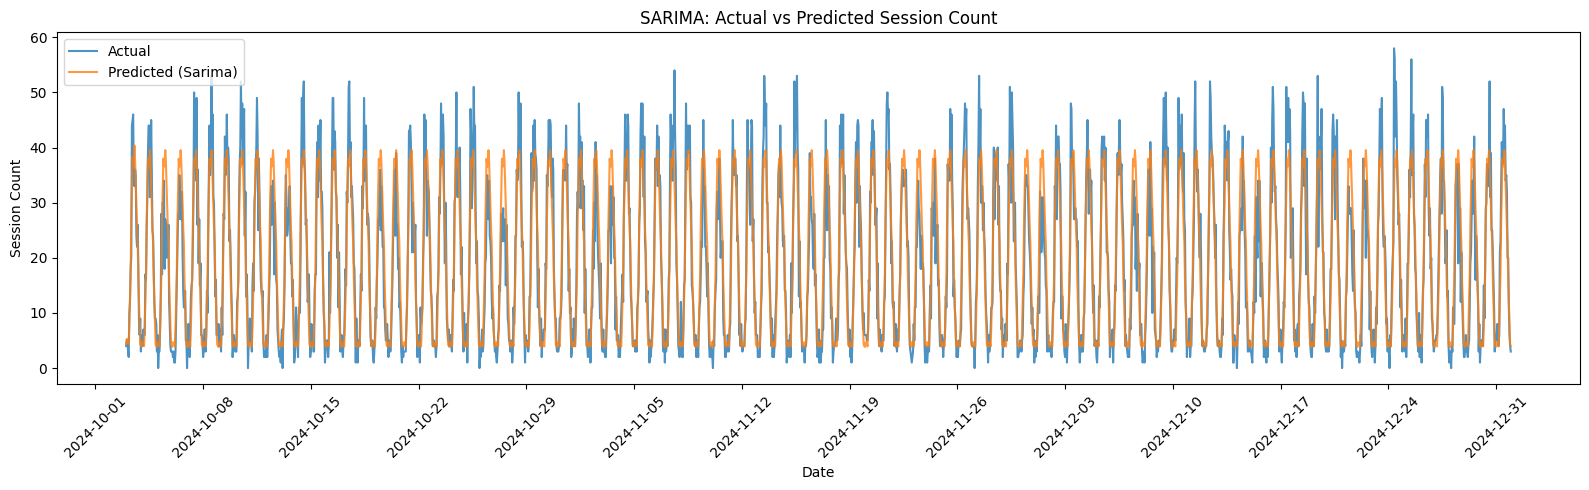

In [9]:
plt.figure(figsize=(16, 5))
plt.plot(test.index, test['session_count'], label='Actual', alpha=0.8)
plt.plot(test.index, pred_session_sarima, label='Predicted (Sarima)', alpha=0.8)
plt.legend()
plt.title('SARIMA: Actual vs Predicted Session Count')
plt.xlabel('Date')
plt.ylabel('Session Count')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

SARIMA's predicted line(orange) closely tracks the timing of the daily demand cycle. Peaks and troughs land in the right place each day, and the weekly pattern (weekday highs, weekend dips) is visibly preserved throughout the test periods. However, the predicted peaks are consistently lower than actual peaks: actual session counts regularly reach 50-58 on high-demand days, while SARIMA's predictions rarely exceed ~40–45. Troughs (near-zero overnight hours) are matched closely on both lines. This means SARIMA is more reliable for predicting when demand will be high than how high it will actually get.

**Plotting actual vs. predicted: Energy (kWh)**

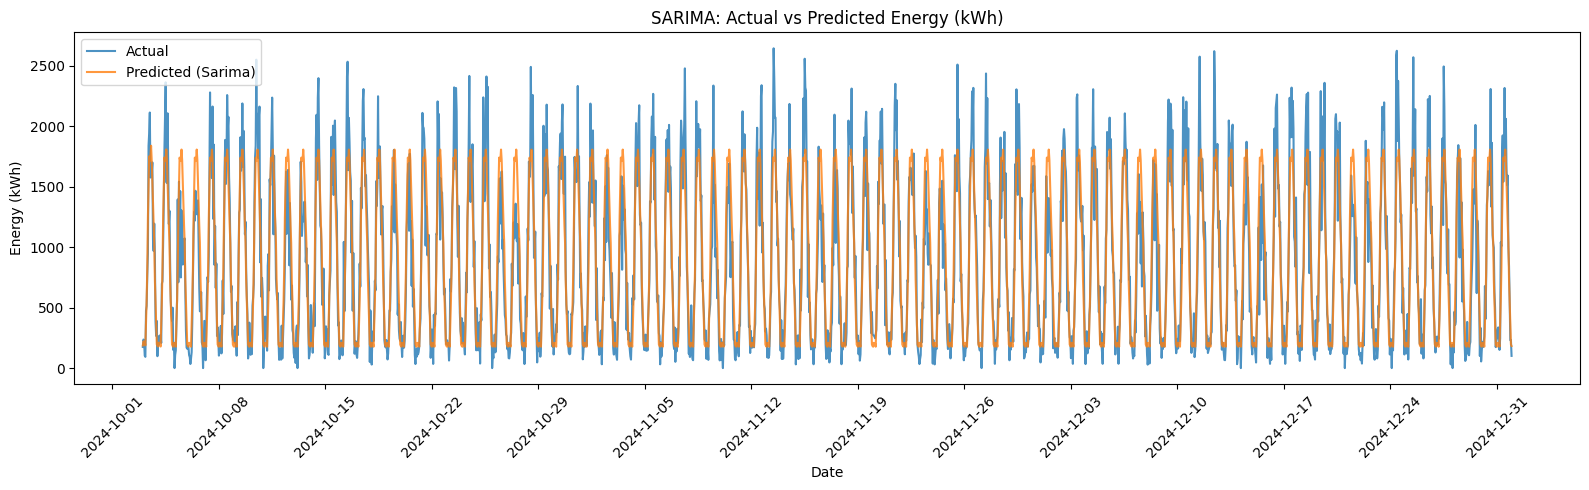

In [10]:
plt.figure(figsize=(16, 5))
plt.plot(test.index, test['total_energy_kwh'], label='Actual', alpha=0.8)
plt.plot(test.index, pred_energy_sarima, label='Predicted (Sarima)', alpha=0.8)
plt.legend()
plt.title('SARIMA: Actual vs Predicted Energy (kWh)')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The same pattern holds for energy. The daily rhythm is well-timed, but the magnitude of the peaks is underestimated. Actual energy demand spikes to 2,000 - 2,600 kWh on multiple days across the test period, while SARIMA's predictions stay compressed closer to a 1,600-1,800 kWh cieling throughout. As with session count, the low-demand troughs are tracked more accurately than the high-demand peaks. The model appears to be fitting towards an "average" cycle rather than capturing the more extreme high-usage days. 

**Combined test results**

In [11]:
results_sarima = pd.DataFrame({
    'target': ['session_count', 'total_energy_kwh'],
    'RMSE': [rmse_session_sarima, rmse_energy_sarima],
    'MAPE': [mape_session_sarima, mape_energy_sarima]
})
results_sarima

,target,RMSE,MAPE
0,session_count,5.461029,0.342386
1,total_energy_kwh,264.722525,0.378930


SARIMA achieved RMSE of 5.46 for session count and 264.72 for energy, with MAPE of 0.342 and0.379 respectively (MAPE calculated excluding zero-demand hours, consistent with the other models). The compressed peak amplitude visible in the charts above is a likely contributor to these error figures, particularly RMSE, which penalizes larger misses more heavily than smaller ones.  

In [12]:
# Build comparison DataFrames before saving
comparison_session = pd.DataFrame({
    'ds': test.index,
    'y': test['session_count'],
    'yhat': pred_session_sarima
})

comparison_energy = pd.DataFrame({
    'ds': test.index,
    'y': test['total_energy_kwh'],
    'yhat': pred_energy_sarima
})

# save output for the next notebook
results_sarima.to_csv('/kaggle/working/results_sarima.csv', index=False)
comparison_session.to_csv('/kaggle/working/comparison_session_sarima.csv', index=False)
comparison_energy.to_csv('/kaggle/working/comparison_energy_sarima.csv', index=False)